<a href="https://colab.research.google.com/github/iestleija/5094-Matematicas/blob/Unidad2/Unidad2/Practices/5094_U2_AB3_266229.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Maestría en Intelingencia Artificial y Analítica de Datos

- Curso: **Matemáticas y estadística para inteligencia artificial**

- Semestre: Enero-Junio

- Profesor: Dra. Helen Clara Peñate Rodríguez
- Actividad: **B3. Derivada y Diferencial de una Función.**
- Alumno: Ismael Estrada Leija
- Matrícula: 266229

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Actividad B3. Derivada y Diferencial de una Función.
Enlace a colab: https://colab.research.google.com/drive/1NSc5a0408A6YJ0dMJ4jgyAVMrHvF8NAh#scrollTo=yND1Ui8dmX5o

1. ¿Compramos el producto?
El archivo excel adjunto Datos compramos el producto muestra la probabilidad de que una persona, con un salario x, compre un producto determinado.
Una función que comunmente se utiliza para modelar este comportamiento es
la función logística:
$$f(x) = \frac {1}
{1 + e^{−(x−x_0)}}$$
donde $x0$ es el punto donde la probabilidad es 0.5. Sin embargo, en términos
de evaluación, es más sencillo evaluar una aproximación polinómica que evaluar
esta función. Es por ello que emplearemos un polinomio de Taylor para describir
estos datos.
1. . Para los datos que se muestran en la tabla diga cuál cree que es el valor de $x_0$
2. Encuentre un polinomio de Taylor de orden 3 para la función logística
alrededor de $x_0$.
3. Evalúe el polinomio obtenido para cada uno de los salarios de la tabla.
4. Encuentre el error de aproximación calculando el valor absoluto de la diferencia de los valores aproximados y los reales.
5. Grafique los valores aproximados y los reales y analice el resultado.

In [ ]:
#probabilidad de compra
probabilidad = pd.read_csv('/content/drive/MyDrive/5094-ClassFiles/Semana04/compramos_el_producto.csv')
probabilidad.describe()

,salario en miles,probabilidad de compra
count,31.000000,31.000000
mean,12.334839,0.554167
std,1.413699,0.278768
min,10.000000,0.116809
25%,11.160000,0.297127
50%,12.340000,0.579349
75%,13.505000,0.814135
max,14.660000,0.933305


##Datos Recibidos

In [ ]:
salario=probabilidad[' salario en miles ']
p_de_compra=probabilidad[' probabilidad de compra ']

##Función Sigmoide
En la descripción de la actividad se encuentra ls función sigmoidea; esta es una función común para mapear cualquier grupo de numeros reales a valores entre 0 y 1.(Singh, 2025) Su definición es asi: $$σ(x) = \frac {1} {1 + e^{-x}}$$
- Los valores positivos grandes se acercan a 1
- El cero es igual 0.5
- Los valore negativos grandes se acercan a 0


#Planteamiento del problema

El tema central de esta actividad es aproximar mediante series de Taylor la funcion subyacente a los datos proporcionados, la cual es: $$f(x) = \frac {1}
{1 + e^{−(x−x_0)}}$$

## $x_0$ = centro de la aproximación
El punto de aproximación adecuado para el conjunto de datos es el promedio de los valores del dominio del eje x, que conforme a la descripción estadística es aproximadamente: 12 y se puede tomar como $x_0$

In [ ]:
x0 = probabilidad[' salario en miles '].mean().round(0)
print(f'El centro de la aproximación es: {x0}')

El centro de la aproximación es: 12.0


## Cálculo de la serie según la función sigmoidea

In [ ]:
# 2. Definir la función original
sigmoide_en_12 = 1 / (1 + np.exp(-(salario - x0)))

# Desarrollo

Conforme a las referencias estudiadas se encuentra que el polinomio de Taylor de tercer grado se describe como:

$P_3(x) = f(a) + \dfrac{f^\prime(a)}{1!}(x-a) + \dfrac{f^{\prime\prime}(a)}{2!} (x-a)^2 + \dfrac{f^{\prime\prime\prime}(a)}{3!} (x-a)^3$

### Derivadas de la función sigmoide
Las siguientes son identidades conocidas para resolver las derivadas de la función sigmoidea.

$σ(x) = \frac {1}
{1 + e^{−(x)}}$

$σ'(x) = σ(x) (1-σ(x))$

$σ''(x) = σ'(x)(1-2σ(x))$

$σ'''(x) = σ''(x)(1-2σ(x))-2(σ'(x))^2$


## Polinomio de Taylor de grado 3 para  $x_0 = a = 12$:

**Cálculo de las derivadas de la función base**

$f(x_0) = \frac {1}
{1 + e^{−(x−x_0)}} = \frac {1} {1 + e ^0} = \frac {1} {2} = 0.5 $
${f'(x_0)} = f(x_0)(1-f(x_0)) = 0.5 (1- 0.5) = 0.25$

$f''(x_0) = 0.25 * (1 - 2 (0.5)) = 0$

$f'''(x_0) = 0 * (1-2*(0.5))-2(0.25)^2 = -0.125$

**Cálculo de la serie de Taylor**

$T_3(x) = f(a) + \dfrac{f^\prime(a)}{1!}(x-a) + \dfrac{f^{\prime\prime}(a)}{2!} (x-a)^2 + \dfrac{f^{\prime\prime\prime}(a)}{3!} (x-a)^3$

$T_3(x) = 0.5 + \frac {0.25}{1} (x -12)+\frac {0}{2}(x-12)^2+\frac {-0.125}{6}(x-12)^2$






##Serie de Taylor Grado 3 en Código

In [ ]:
Taylor_3 = lambda x : 0.5 +  0.25*(x - x0) - (1/48)*((x-x0)**3)

##Errores
Se calcula el valor absoluto de la diferencia entre la aproximación y los datos recibidos, y por otro lado se genera una serie con los errores para graficar.


In [ ]:
# Calculamos la norma Euclideana del error
Error_T3 = np.linalg.norm(Taylor_3(salario) - sigmoide_en_12, 2)

print('||T3(salario) - sigmoide_en_12(salario)|| = {:10.8}'.format(Error_T3))

errores = np.abs(Taylor_3(salario) - sigmoide_en_12) # serie para graficar

||T3(salario) - sigmoide_en_12(salario)|| = 0.25511854


#Resultados
En la siguiente gráfica se puede observar como los datos recibidos y la función sigmoidea coinciden perfectamente y de la misma forma la aproximación mediante el polinomio de Taylor de grado 3 permanece muy cercano en el rango de salario de 11 a 13.

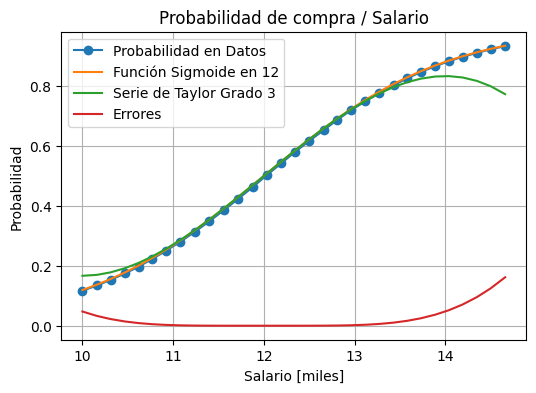

In [ ]:

plt.figure(figsize=(6,4)) # Optional: set the size of the figure
plt.plot(salario, p_de_compra, marker='o', label="Probabilidad en Datos")
plt.plot(salario, sigmoide_en_12, label="Función Sigmoide en 12")
plt.plot(salario, Taylor_3(salario), label="Serie de Taylor Grado 3")
plt.plot(salario, errores, label="Errores")
plt.xlabel("Salario [miles]")
plt.ylabel("Probabilidad")
plt.grid()
plt.title("Probabilidad de compra / Salario")
plt.legend();

#Conclusión
Se analizó la función subyacente a los datos proporcionados, se generó un polinomio de Taylor de tercer grado para establecer una aproximación en las cercanías del promedio del rango de el eje x.

Finalmente se desplegaron los resultados superpuestos en una gráfica que muestra elocuentmente la relación entre los datos recibidos, la función sigmoidea y la aproximación lograda con el polinomio de Taylor. Adicionalmente se agregó una serie para graficar los errores.

Lo anterior se realizó con el uso de las librerías Pandas, (Pandas team, 2026) Numpy (NumPy team, 2026) y Matplotlib (Hunter et al., 2026) de Python y con el apoyo de los recursos proporcionados por la docente y especialmente con las Series de Taylor Luis M. de la Cruz (Cruz Salas, 2020)


#Referencias

Hunter, J., Dale, D., Firing, E., & Droettboom, M. (2026). Pyplot tutorial—Matplotlib 3.10.8 documentation. Pyplot tutorial. https://matplotlib.org/stable/tutorials/pyplot.html

NumPy team. (2026). NumPy. https://numpy.org/

Pandas team. (2026). pandas documentation—Pandas 3.0.0 documentation. https://pandas.pydata.org/docs/index.html

Singh, V. (2025). La función sigmoidea: Un componente clave en la ciencia de datos. https://www.datacamp.com/tutorial/sigmoid-function